### Step 0 :- Data Collection :-  https://www.kaggle.com/datasets/nitinchoudhary012/algerian-forest-fires-dataset

### Attribute Information:

`1. Date :` (DD/MM/YYYY) Day, month ('june' to 'september'), year (2012)
Weather data observations

`2. Temp :` temperature noon (temperature max) in Celsius degrees: 22 to 42

`3. RH :` Relative Humidity in %: 21 to 90

`4. Ws :`Wind speed in km/h: 6 to 29

`5. Rain:` total day in mm: 0 to 16.8
FWI Components

`6. Fine Fuel Moisture Code (FFMC) index from the FWI system:` 28.6 to 92.5

`7. Duff Moisture Code (DMC) index from the FWI system:` 1.1 to 65.9

`8. Drought Code (DC) index from the FWI system:` 7 to 220.4

`9. Initial Spread Index (ISI) index from the FWI system:` 0 to 18.5

`10. Buildup Index (BUI) index from the FWI system:` 1.1 to 68

`11. Fire Weather Index (FWI) Index:` 0 to 31.1

`12. Classes:` two classes, namely Fire and not Fire

### Step 1 :- Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns",None)

### Step 2 :- Load dataset / Read dataset

In [3]:
df = pd.read_csv('Data/Algerian_forest_fires_cleaned_dataset.csv')
df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,26,9,2012,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire,1
239,27,9,2012,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire,1
240,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
241,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


### Step 3 :- Data Overview

In [4]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


In [6]:
print("No of Rows    :-",df.shape[0])
print("No of Columns :-",df.shape[1])

No of Rows    :- 243
No of Columns :- 15


### Stpe 4 :- Data Cleaning

In [11]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [12]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [14]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'),0,1)

In [15]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [16]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [17]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [27]:
plt.style.use('seaborn-v0_8-white')

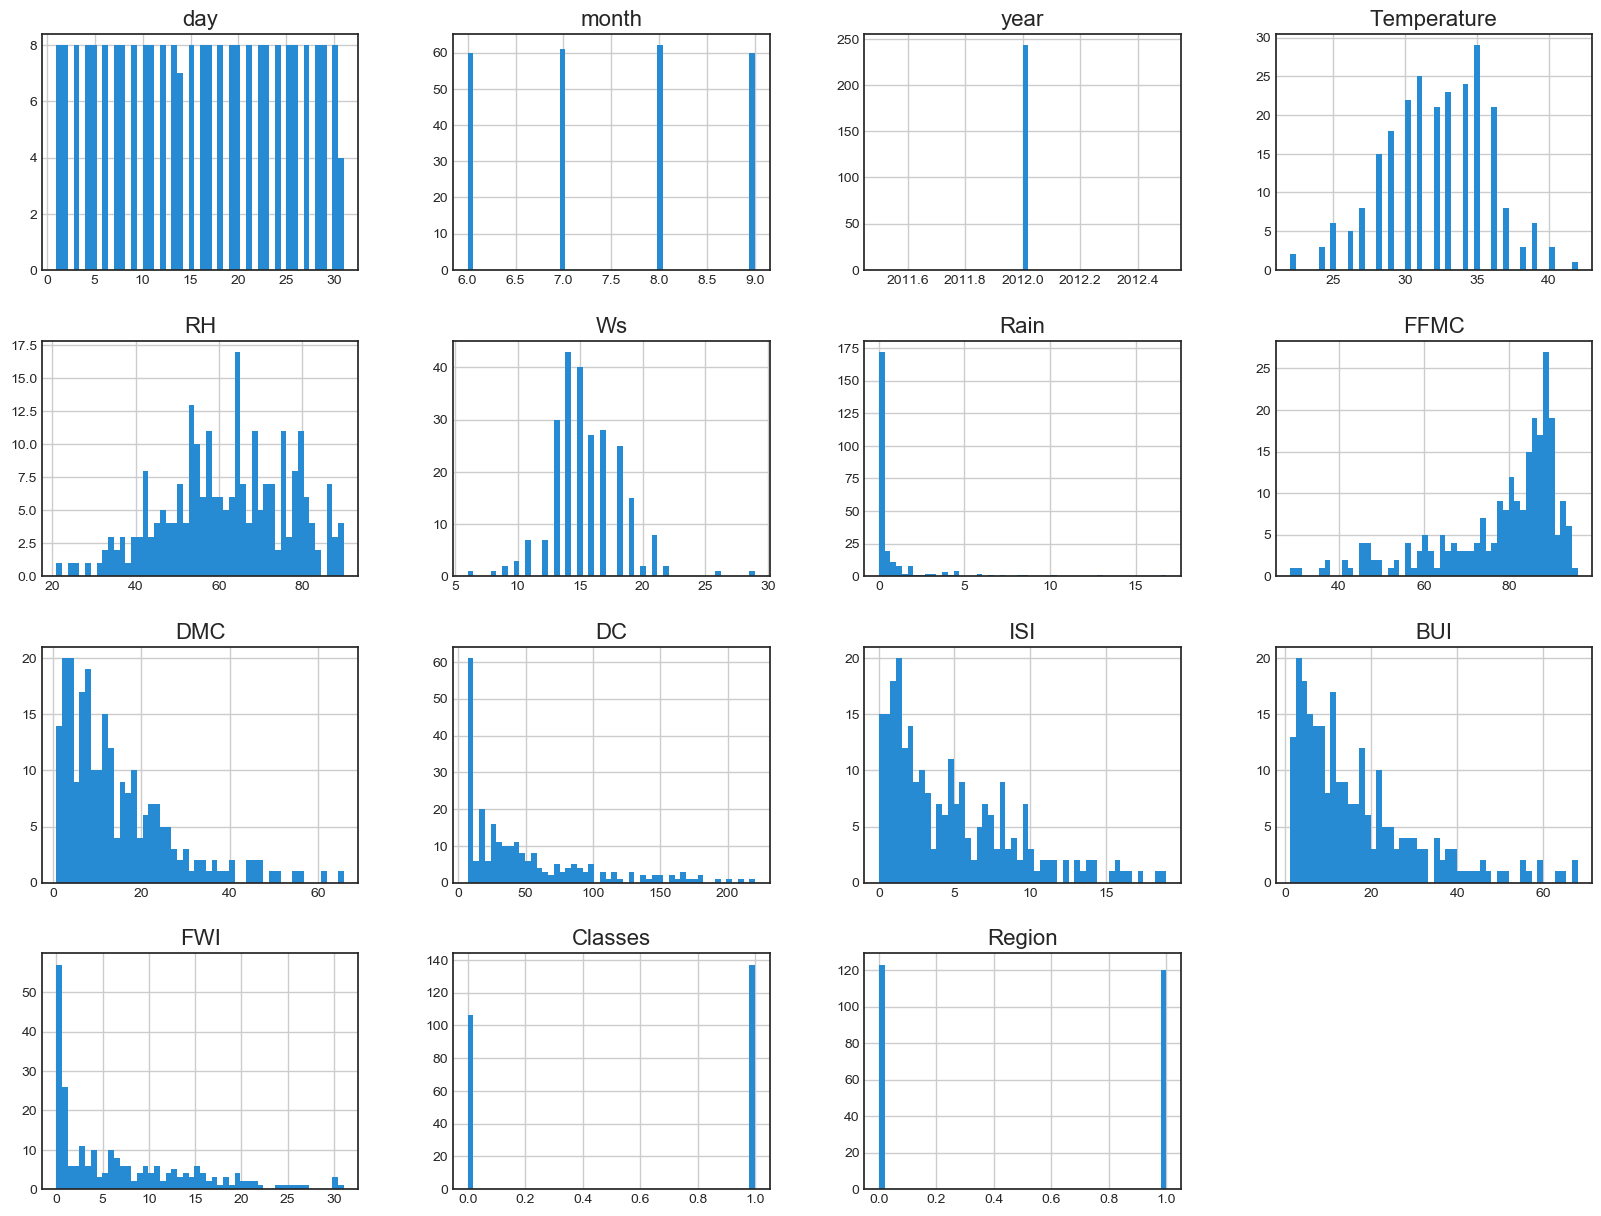

In [28]:
df.hist(bins=50,figsize=(20,15))
plt.show()

In [29]:
percentage = df['Classes'].value_counts(normalize=True) * 100
percentage

Classes
1    56.378601
0    43.621399
Name: proportion, dtype: float64

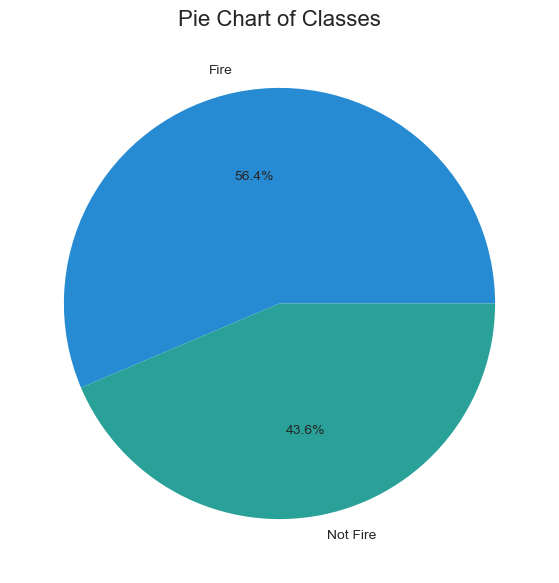

In [30]:
classlabels=["Fire","Not Fire"]
plt.figure(figsize=(12,7))
plt.pie(percentage,labels=classlabels,autopct='%1.1f%%')
plt.title("Pie Chart of Classes")
plt.show()

In [32]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [37]:
correlation = df[['Temperature', 'RH', 'Ws', 'Rain', 'FFMC','DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region']].corr()
correlation

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269920
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.407692
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.170922
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.039756
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.234178
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.200209
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.071605
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.271439
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.097467
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.204693


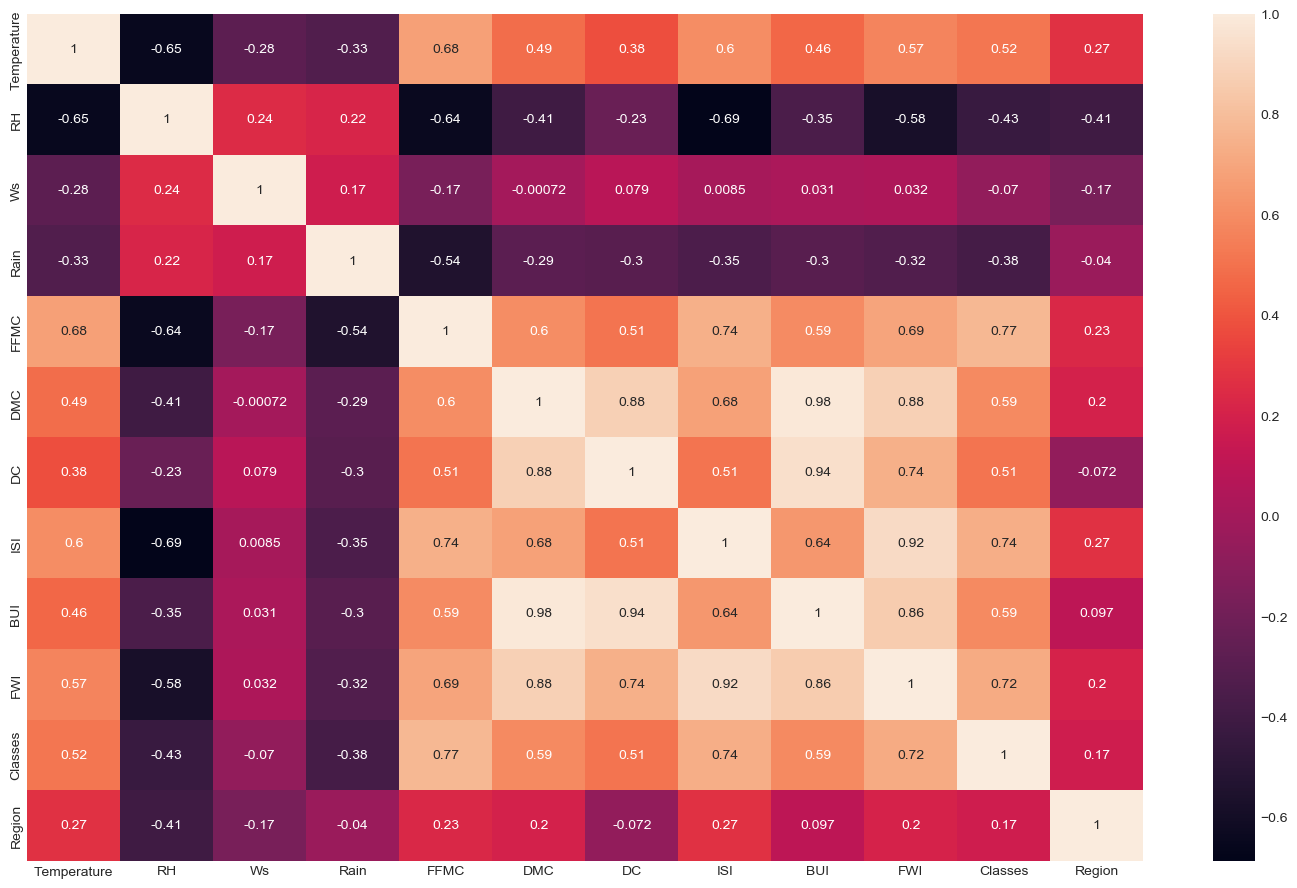

In [40]:
plt.figure(figsize=(18,11))
sns.heatmap(correlation,annot=True)
plt.show()

### Create bivarite Analysis from above graph

In [41]:
df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,26,9,2012,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,27,9,2012,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1


In [42]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [43]:
df2 = df[['Temperature', 'RH', 'Ws', 'Rain', 'FFMC','DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region']]
df2

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1


In [45]:
# Independent and dependent vaiables

X = df2.drop(columns='FWI')
y= df2['FWI']

In [46]:
X.shape

(243, 11)

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test =  train_test_split(X,y,test_size=0.2,random_state=42)

In [52]:
X_train.shape , X_test.shape

((194, 11), (49, 11))

In [53]:
y_train.shape , y_test.shape

((194,), (49,))

### Model Buliding

#### Linear Regression

In [54]:
from sklearn.linear_model import LinearRegression

Model_1 = LinearRegression()

Model_1.fit(X_train,y_train)

LinearRegression()

In [66]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score ,accuracy_score

### Test data

In [62]:
y_prad = Model_1.predict(X_test)
y_prad

array([ 8.30089006,  7.52273246, -0.07739645,  5.09515145,  6.55667384,
        1.38464606,  2.2211388 ,  7.51313613,  1.90064132,  3.19396653,
        0.02384729,  7.36285986,  9.51542116, 16.44866991, 19.06612789,
        1.2936555 ,  2.20127165, -0.02816601,  6.77696296,  3.15789192,
        1.23769961,  0.2021465 ,  6.4791346 ,  0.0909881 , 21.13658675,
        4.9399134 ,  5.87034478,  9.94612403,  0.19366324,  9.68660273,
        6.29993038, -0.11842966, 10.26800727, 14.99470671,  1.33024475,
        0.62076824,  1.8289408 ,  6.1263634 , -0.34635007, -0.61651216,
        7.04501511,  1.66258846,  8.5066524 , -0.3834532 , 15.29442806,
        7.89155386,  7.66943313,  1.06298168, 12.53487906])

### Train data

In [63]:
y_train_prad = Model_1.predict(X_train)
y_train_prad

array([ 0.85752192, 28.79762267,  5.46974224, 17.19571402, 20.06516531,
       14.32035302, 16.49078231,  0.70119619,  8.7616346 ,  3.63637628,
       14.73495303,  5.06657554,  0.72254653, -0.34221587, 22.03290309,
        3.14382847,  1.33698992,  9.58386428,  6.91728743, 10.35396135,
       -0.42940537,  8.13388369, 12.33630096, 15.69629508, 12.65840654,
       -0.03101664,  1.40021602,  0.05916226,  2.77091696, 14.42808666,
       -0.61738828,  9.17826886,  5.39566152,  6.23959595,  9.16031467,
       28.85430519,  0.64986795, -0.08508093,  0.79034675,  6.88950593,
        5.63350582,  2.99263013, -0.3627752 ,  0.69944469,  1.59619665,
        4.48640538, -0.16567851, -0.07922821, 19.8283826 ,  4.71946496,
        1.25654971, 14.15213847, 11.57303017, 14.86130986,  1.27704395,
       14.24955652, 12.98968196,  3.43371716,  0.26281702, 24.86445405,
        0.3174711 , -0.25571165, 13.69818472,  3.9141437 , -0.25029576,
       20.14927488,  6.35995957, 17.0335923 ,  7.8380267 , 20.10

In [64]:
MSE_test = mean_squared_error(y_test,y_prad)
MSE_train = mean_squared_error(y_train,y_train_prad)

print(f"Test Data :- {MSE_test}")
print(f"Train Data :- {MSE_train}")

Test Data :- 0.33330057445675143
Train Data :- 1.5899563466105744


In [67]:
MAE_test = mean_absolute_error(y_test,y_prad)
MAE_train = mean_absolute_error(y_train,y_train_prad)

print(f"Test Data :- {MAE_test}")
print(f"Train Data :- {MAE_train}")

Test Data :- 0.42800123368927145
Train Data :- 0.6758990964998512


In [69]:
r2_score(y_test,y_prad)

0.9890030375037768

In [70]:
r2_score(y_train,y_train_prad)

0.9737936612855493

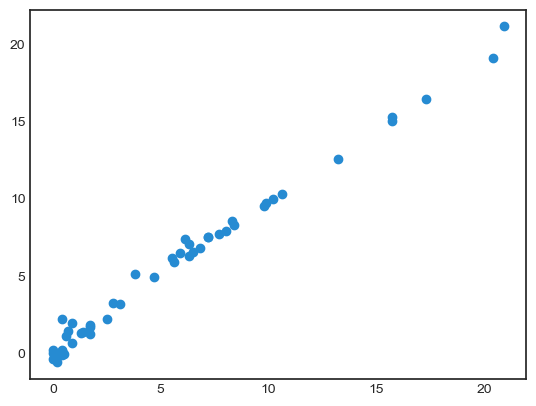

In [72]:
plt.scatter(y_test,y_prad)

In [73]:
from sklearn.linear_model import Lasso

Model_2 = Lasso()

Model_2.fit(X_train,y_train)

Lasso()

In [75]:
y_prad_2 = Model_2.predict(X_test)
y_prad_2

array([ 8.12060433,  7.26381863,  0.24211661,  6.09099515,  6.86026934,
        1.9574925 ,  2.57996436,  7.72745562,  2.19047985,  3.72049532,
        0.61212933, 11.82404487,  9.56931118, 16.34119317, 18.64577173,
        2.03342946,  2.08601346, -1.32825065,  6.68199062,  3.50720582,
        1.87245725,  0.18943274,  6.18708654, -0.07411673, 20.10032301,
        5.00409533,  5.80910163,  9.84903446, -1.45296618,  9.81363931,
        6.2276863 ,  0.17740642, 10.10957088, 14.90742213,  1.85083082,
        1.47331839,  1.85891994,  6.47369219, -0.69295258, -0.62254418,
        7.15573154,  2.16858732,  8.27088954, -1.47041385, 15.15532615,
        7.81098088,  7.96128562,  0.98639686, 12.70179162])

In [76]:
y_train_prad_2 = Model_2.predict(X_train)
y_train_prad_2

array([ 1.06131166e+00,  2.85155843e+01,  5.84644107e+00,  1.63813323e+01,
        1.95879946e+01,  1.40335591e+01,  1.65833147e+01,  1.40448123e+00,
        8.96948872e+00,  3.97284416e+00,  1.46523125e+01,  5.42373300e+00,
        1.43879967e+00, -1.61169557e-01,  2.10361190e+01,  3.68727863e+00,
        1.66079556e+00,  9.38395723e+00,  7.03520766e+00,  1.04671802e+01,
       -1.34368422e+00,  7.75123413e+00,  1.20834379e+01,  1.54421160e+01,
        1.23307201e+01, -8.01687813e-01,  1.66340179e+00,  9.80257041e-01,
        2.71814398e+00,  1.40680045e+01, -9.73564951e-01,  9.32457779e+00,
        5.67741333e+00,  6.16799383e+00,  9.41751347e+00,  2.84138841e+01,
        1.33042383e+00, -4.35111769e-01,  3.58782902e-01,  6.71618435e+00,
        6.16767154e+00,  3.64895924e+00, -6.00737815e-01,  1.58712851e+00,
        2.36783954e+00,  4.94612501e+00,  9.27273771e-02,  1.66125112e-01,
        1.90320982e+01,  5.29380430e+00,  1.65869082e+00,  1.40814670e+01,
        1.15686588e+01,  

In [77]:
MAE_test = mean_absolute_error(y_test,y_prad_2)
MAE_train = mean_absolute_error(y_train,y_train_prad_2)

print(f"Test Data :- {MAE_test}")
print(f"Train Data :- {MAE_train}")

Test Data :- 0.7118785759425905
Train Data :- 0.8464679370254053


In [80]:
r2_score(y_test,y_prad_2)

0.957487715329232

In [82]:
r2_score(y_train,y_train_prad_2)

0.9693402743831869

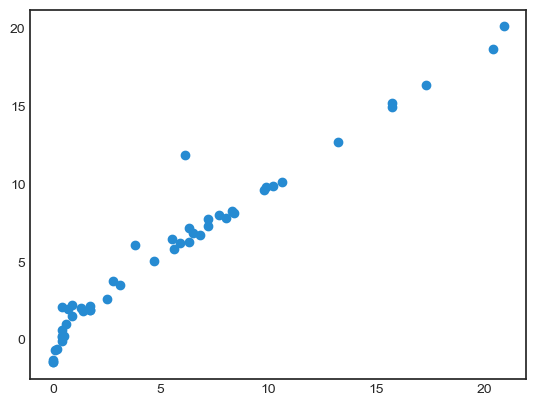

In [83]:
plt.scatter(y_test,y_prad_2)